# Caminhada Quântica 1D com Duas Moedas de Hadamard
## Emaranhamento via Entropia de von Neumann

**Espaço de estados:**  
$$|\psi\rangle \in \mathcal{H}_{\text{pos}} \otimes \mathcal{H}_{C_1} \otimes \mathcal{H}_{C_2}$$

A cada passo calcula-se a **entropia de von Neumann** da moeda $C_1$ após traçar sobre posição e $C_2$:

$$S(\rho_{C_1}) = -\text{Tr}(\rho_{C_1} \ln \rho_{C_1}) = -\lambda_1 \ln \lambda_1 - \lambda_2 \ln \lambda_2$$

O máximo possível para um qubit é $S_{\max} = \ln 2 \approx 0.693$ nats.


## 1. Imports e configuração

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.linalg import eigvalsh

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=[
        "#534AB7", "#378ADD", "#D85A30", "#0F6E56",
        "#BA7517", "#A32D2D", "#888780",
    ]),
    "font.size": 11,
})
LN2 = np.log(2)          # entropia máxima de 1 qubit (nats)
SQ2 = np.sqrt(2)


## 2. Operadores quânticos

In [2]:
# ── Moeda de Hadamard ─────────────────────────────────────────────────────────
H = np.array([[1, 1],
              [1,-1]], dtype=complex) / SQ2

# ── Moeda dupla H⊗H (4×4) ────────────────────────────────────────────────────
HH = np.kron(H, H)   # age no espaço de spin {|00>, |01>, |10>, |11>}

print("H =")
print(np.round(H, 4))
print()
print("H⊗H =")
print(np.round(HH, 4))


H =
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]

H⊗H =
[[ 0.5+0.j  0.5+0.j  0.5+0.j  0.5+0.j]
 [ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]
 [ 0.5+0.j  0.5+0.j -0.5+0.j -0.5+0.j]
 [ 0.5+0.j -0.5+0.j -0.5+0.j  0.5-0.j]]


## 3. Operador de coin e shift

In [3]:
def coin_operator_2(state: np.ndarray) -> np.ndarray:
    """
    Aplica H⊗H a cada posição x do estado.

    state: shape (n_positions, 4)
           eixo 1 → base {|00>, |01>, |10>, |11>}
    """
    # einsum 'ij, xj -> xi' : multiplica HH por state[x] para todo x
    return np.einsum("ij,xj->xi", HH, state)


def shift_operator_2(state: np.ndarray) -> np.ndarray:
    """
    Shift condicional em C1 (1ª moeda):
      C1 = |0> → anda para a DIREITA (+1)   [componentes 00, 01]
      C1 = |1> → anda para a ESQUERDA (-1)  [componentes 10, 11]

    C2 é arrastado junto — é aí que nasce o emaranhamento posição-moeda.

    state: shape (n_positions, 4)
    """
    n = state.shape[0]
    new = np.zeros_like(state)
    for x in range(n):
        # C1=|0> → direita: componentes índice 0 (|00>) e 1 (|01>)
        if x + 1 < n:
            new[x + 1, 0] += state[x, 0]  # |00>
            new[x + 1, 1] += state[x, 1]  # |01>
        # C1=|1> → esquerda: componentes índice 2 (|10>) e 3 (|11>)
        if x - 1 >= 0:
            new[x - 1, 2] += state[x, 2]  # |10>
            new[x - 1, 3] += state[x, 3]  # |11>
    return new


## 4. Matriz densidade reduzida e Entropia de von Neumann

In [4]:
def reduced_density_coin1(state: np.ndarray) -> np.ndarray:
    """
    Calcula ρ_{C1} traçando sobre posição e C2.

    Passos:
      1. ρ_{C1C2} = Tr_pos(|ψ><ψ|)  →  soma |ψ(x)><ψ(x)| em x
      2. ρ_{C1}   = Tr_{C2}(ρ_{C1C2})

    Retorna: matriz 2×2 complexa
    """
    n_pos = state.shape[0]

    # ── Passo 1: ρ_{C1C2} = Σ_x |ψ(x)><ψ(x)|  (4×4)
    rho_c1c2 = np.einsum("xi,xj->ij", state, state.conj())

    # ── Passo 2: ρ_{C1}_{a,b} = Σ_{c2} ρ_{C1C2}_{a*2+c2, b*2+c2}
    # Reshape para (c1_a, c2_a, c1_b, c2_b) e traça c2
    rho_r = rho_c1c2.reshape(2, 2, 2, 2)       # (c1_a, c2_a, c1_b, c2_b)
    rho_c1 = np.trace(rho_r, axis1=1, axis2=3)  # traça c2_a=c2_b → (c1_a, c1_b)

    return rho_c1


def von_neumann_entropy(rho: np.ndarray) -> float:
    """
    S(ρ) = -Tr(ρ ln ρ) = -Σ λ_i ln λ_i
    Usa autovalores reais de eigvalsh (matriz hermitiana).
    """
    eigs = eigvalsh(rho).real
    eigs = np.clip(eigs, 0, None)          # elimina ruído numérico < 0
    eigs = eigs[eigs > 1e-15]              # evita 0·ln(0)
    return float(-np.sum(eigs * np.log(eigs)))


# ── Teste rápido: estado maximamente emaranhado ───────────────────────────────
bell = np.array([[1, 0, 0, 1]], dtype=complex) / SQ2   # 1 posição, |Φ+>
rho_test = reduced_density_coin1(bell)
S_test = von_neumann_entropy(rho_test)
print(f"Bell state |Φ+>  →  S = {S_test:.6f}  (esperado ln2 = {LN2:.6f})")


Bell state |Φ+>  →  S = 0.693147  (esperado ln2 = 0.693147)


## 5. Estados iniciais das moedas

In [5]:
INITIAL_STATES = {
    "|+>|+> simétrico": np.array([1, 1, 1, 1], dtype=complex) / 2,
    "|0>|0> separável": np.array([1, 0, 0, 0], dtype=complex),
    "|Φ+> Bell state":  np.array([1, 0, 0, 1], dtype=complex) / SQ2,
    "|0>|1> anti-sim.": np.array([0, 1, 0, 0], dtype=complex),
}

print("Estados iniciais disponíveis:")
for name, vec in INITIAL_STATES.items():
    norm = np.linalg.norm(vec)
    S0 = von_neumann_entropy(reduced_density_coin1(vec.reshape(1, 4)))
    print(f"  {name:25s}  |norm|={norm:.4f}  S_0={S0:.4f} nats")


Estados iniciais disponíveis:
  |+>|+> simétrico           |norm|=1.0000  S_0=-0.0000 nats
  |0>|0> separável           |norm|=1.0000  S_0=-0.0000 nats
  |Φ+> Bell state            |norm|=1.0000  S_0=0.6931 nats
  |0>|1> anti-sim.           |norm|=1.0000  S_0=-0.0000 nats


## 6. Simulador principal

In [6]:
def quantum_walk_2coins(n_steps: int, coin_init: np.ndarray) -> dict:
    """
    Executa a caminhada quântica com 2 moedas de Hadamard.

    Parâmetros
    ----------
    n_steps    : número de passos
    coin_init  : array (4,) com estado inicial das moedas (normalizado)

    Retorna
    -------
    dict com:
      'state'     : estado final (n_positions, 4)
      'prob'      : distribuição de probabilidade P(x) final
      'entropy'   : S(ρ_C1) em cada passo   shape (n_steps,)
      'positions' : array de posições        shape (n_positions,)
    """
    n_pos  = 2 * n_steps + 1
    center = n_steps

    # ── Estado inicial: andarilho no centro ──────────────────────────────
    state = np.zeros((n_pos, 4), dtype=complex)
    state[center] = coin_init / np.linalg.norm(coin_init)

    entropies = np.zeros(n_steps)

    for step in range(n_steps):
        state = coin_operator_2(state)
        state = shift_operator_2(state)
        rho_c1 = reduced_density_coin1(state)
        entropies[step] = von_neumann_entropy(rho_c1)

    prob = np.sum(np.abs(state) ** 2, axis=1)
    positions = np.arange(n_pos) - center

    return {
        "state":     state,
        "prob":      prob,
        "entropy":   entropies,
        "positions": positions,
    }


# ── Referência: 1 moeda de Hadamard ──────────────────────────────────────────
def quantum_walk_1coin(n_steps: int) -> dict:
    """Caminhada de referência com 1 moeda Hadamard e estado simétrico."""
    n_pos  = 2 * n_steps + 1
    center = n_steps
    state  = np.zeros((n_pos, 2), dtype=complex)
    state[center] = np.array([1, 1j]) / SQ2

    for _ in range(n_steps):
        ns = np.zeros_like(state)
        # coin
        out = np.einsum("ij,xj->xi",
                        np.array([[1,1],[1,-1]], dtype=complex) / SQ2,
                        state)
        for x in range(n_pos):
            if x + 1 < n_pos: ns[x+1, 0] += out[x, 0]
            if x - 1 >= 0:    ns[x-1, 1] += out[x, 1]
        state = ns

    prob = np.sum(np.abs(state) ** 2, axis=1)
    return {"prob": prob, "positions": np.arange(n_pos) - center}


## 7. Parâmetros de simulação

In [7]:
# ══════════════════════════════════════════════════════
#  AJUSTE AQUI OS PARÂMETROS
# ══════════════════════════════════════════════════════
N_STEPS      = 80          # número de passos
COIN_INIT_KEY = "|+>|+> simétrico"   # escolha da lista INITIAL_STATES

# ──────────────────────────────────────────────────────
coin_init = INITIAL_STATES[COIN_INIT_KEY]
result    = quantum_walk_2coins(N_STEPS, coin_init)
ref1      = quantum_walk_1coin(N_STEPS)

print(f"Simulação concluída: {N_STEPS} passos, estado '{COIN_INIT_KEY}'")
print(f"  S máxima  : {result['entropy'].max():.6f} nats  (ln2 = {LN2:.6f})")
print(f"  S final   : {result['entropy'][-1]:.6f} nats")
print(f"  passo S_max: {result['entropy'].argmax() + 1}")
print(f"  soma P(x)  : {result['prob'].sum():.10f}  (deve ser 1)")


Simulação concluída: 80 passos, estado '|+>|+> simétrico'
  S máxima  : 0.693147 nats  (ln2 = 0.693147)
  S final   : 0.574368 nats
  passo S_max: 2
  soma P(x)  : 1.0000000000  (deve ser 1)


## 8. Gráfico principal — Emaranhamento + Distribuição

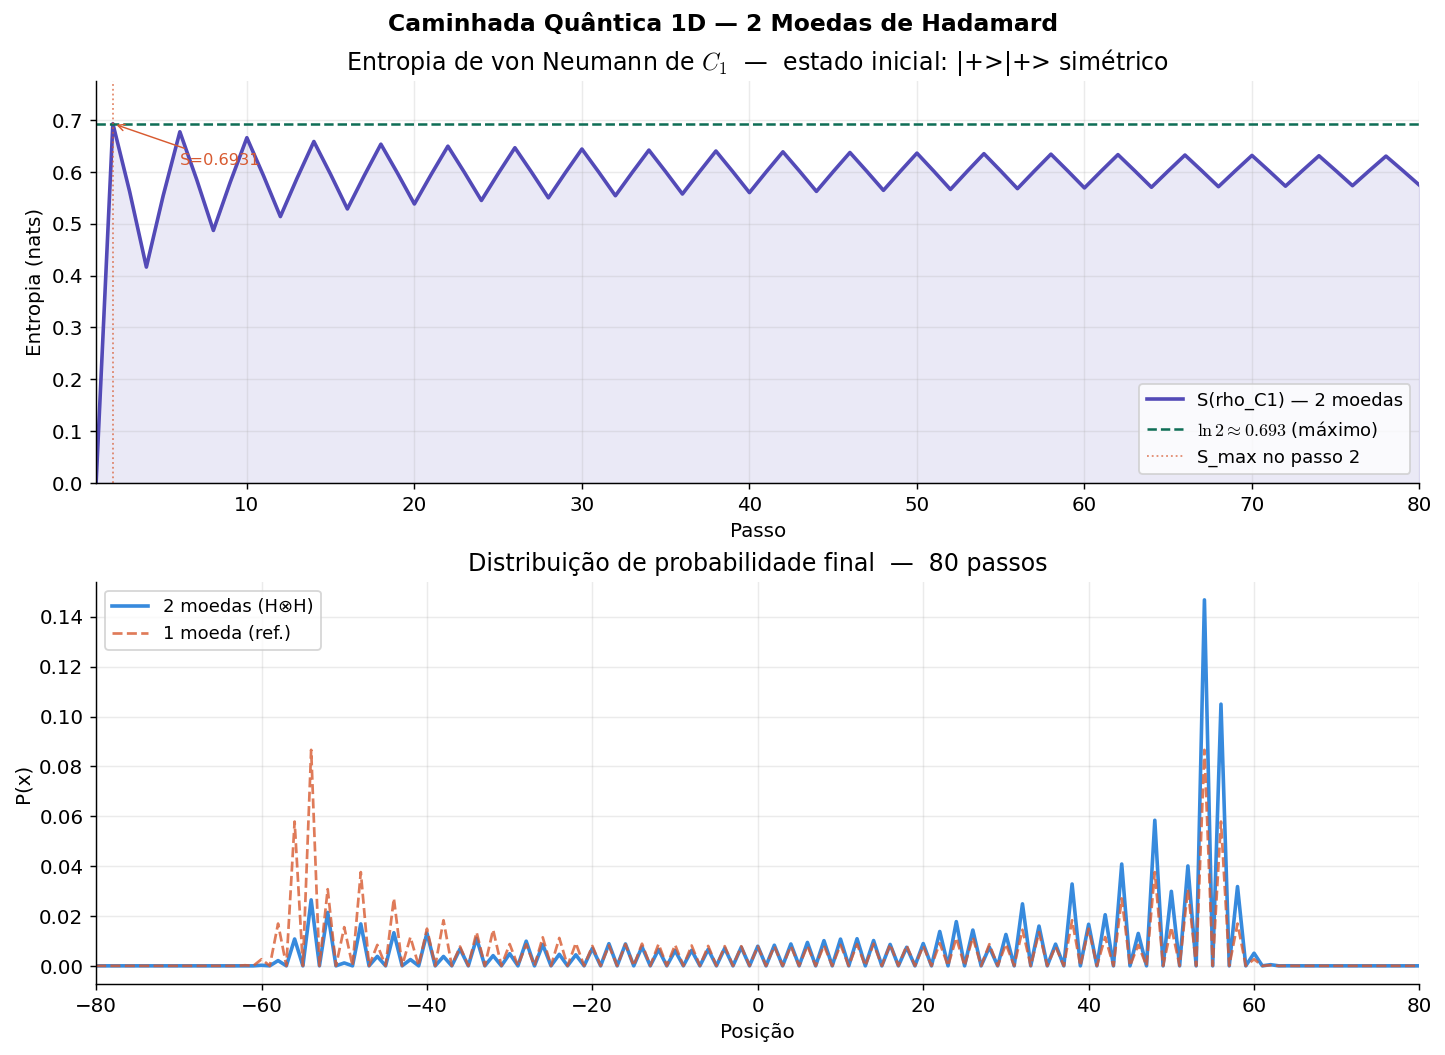

Figura salva: walk_2coins_main.png


In [8]:
steps = np.arange(1, N_STEPS + 1)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)

# ── Painel superior: Entropia de von Neumann ──────────────────────────────────
ax = axes[0]
ax.fill_between(steps, result["entropy"], alpha=0.12, color="#534AB7")
ax.plot(steps, result["entropy"], color="#534AB7", lw=2.0,
        label="S(rho_C1) — 2 moedas")
ax.axhline(LN2, color="#0F6E56", lw=1.4, ls="--",
           label=r"$\ln 2 \approx 0.693$ (máximo)")
ax.axvline(result["entropy"].argmax() + 1, color="#D85A30",
           lw=1, ls=":", alpha=0.7,
           label=f"S_max no passo {result['entropy'].argmax()+1}")
ax.set_xlabel("Passo")
ax.set_ylabel("Entropia (nats)")
ax.set_title(f"Entropia de von Neumann de $C_1$  —  estado inicial: {COIN_INIT_KEY}")
ax.set_xlim(1, N_STEPS)
ax.set_ylim(0, LN2 * 1.12)
ax.legend(fontsize=10)

# Anotação do valor máximo
ymax = result["entropy"].max()
xmax = result["entropy"].argmax() + 1
ax.annotate(f"S={ymax:.4f}", xy=(xmax, ymax),
            xytext=(xmax + N_STEPS*0.05, ymax - 0.08),
            fontsize=9, color="#D85A30",
            arrowprops=dict(arrowstyle="->", color="#D85A30", lw=0.8))

# ── Painel inferior: Distribuição de probabilidade ────────────────────────────
ax2 = axes[1]
ax2.plot(result["positions"], result["prob"],
         color="#378ADD", lw=2.0, label="2 moedas (H⊗H)")
ax2.plot(ref1["positions"], ref1["prob"],
         color="#D85A30", lw=1.5, ls="--", alpha=0.8, label="1 moeda (ref.)")
ax2.set_xlabel("Posição")
ax2.set_ylabel("P(x)")
ax2.set_title(f"Distribuição de probabilidade final  —  {N_STEPS} passos")
ax2.set_xlim(-N_STEPS, N_STEPS)
ax2.legend(fontsize=10)

plt.suptitle("Caminhada Quântica 1D — 2 Moedas de Hadamard", fontsize=13, fontweight="bold")
plt.savefig("walk_2coins_main.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: walk_2coins_main.png")


## 9. Evolução temporal do emaranhamento para todos os estados iniciais

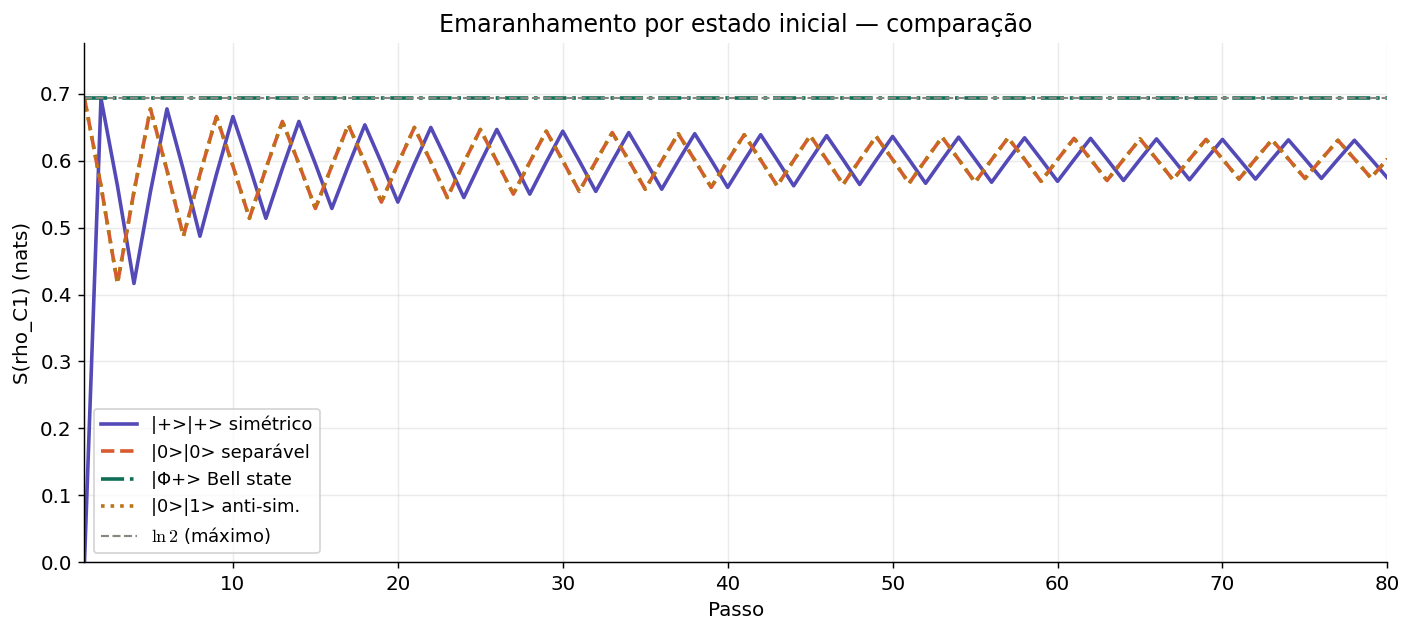

Figura salva: walk_entropy_comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = ["#534AB7", "#D85A30", "#0F6E56", "#BA7517"]
linestyles = ["-", "--", "-.", ":"]

for (name, coinvec), col, ls in zip(INITIAL_STATES.items(), colors, linestyles):
    res = quantum_walk_2coins(N_STEPS, coinvec)
    ax.plot(steps, res["entropy"], color=col, ls=ls, lw=2.0, label=name)

ax.axhline(LN2, color="#888780", lw=1.2, ls="--", label=r"$\ln 2$ (máximo)")
ax.set_xlabel("Passo")
ax.set_ylabel("S(rho_C1) (nats)")
ax.set_title("Emaranhamento por estado inicial — comparação")
ax.set_xlim(1, N_STEPS)
ax.set_ylim(0, LN2 * 1.12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("walk_entropy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: walk_entropy_comparison.png")


## 10. Evolução espacial da probabilidade (heatmap)

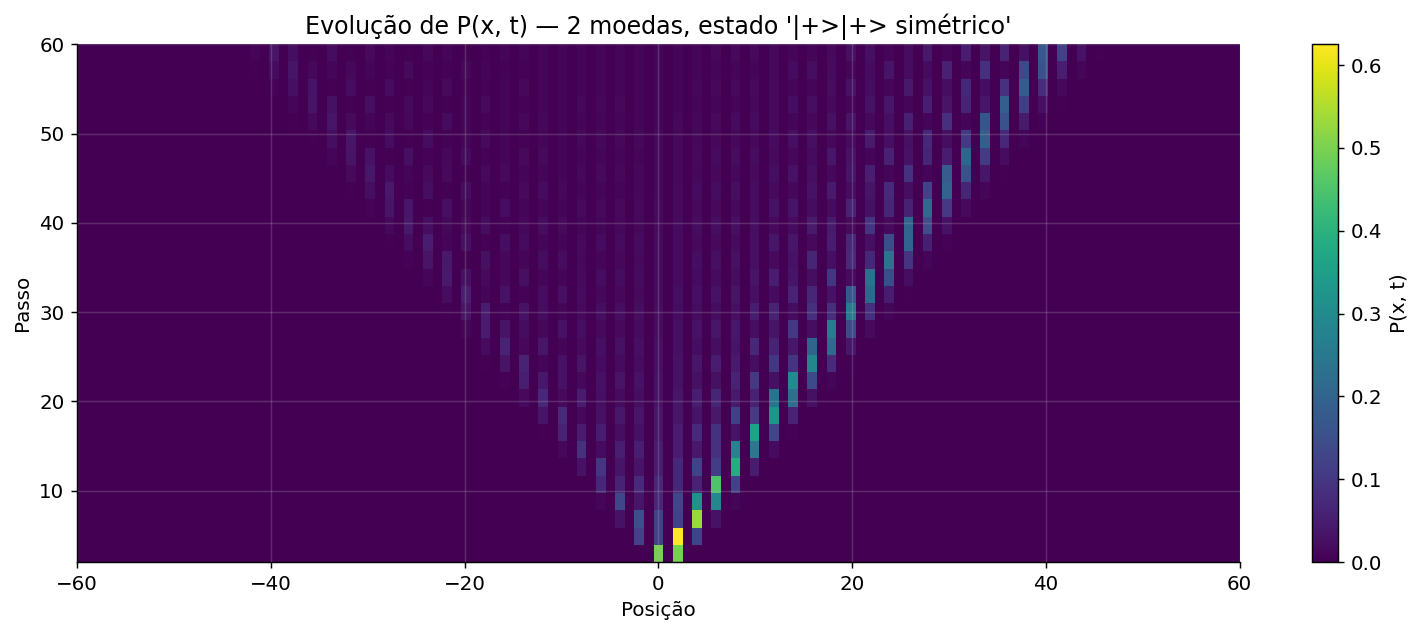

Figura salva: walk_heatmap.png


In [10]:
N_SNAP   = 60    # número de passos para o heatmap
SNAP_KEY = "|+>|+> simétrico"

probs_over_time = []
snap_coinvec = INITIAL_STATES[SNAP_KEY]
n_pos_snap   = 2 * N_SNAP + 1
center_snap  = N_SNAP

state_h = np.zeros((n_pos_snap, 4), dtype=complex)
state_h[center_snap] = snap_coinvec / np.linalg.norm(snap_coinvec)

for step in range(N_SNAP):
    state_h = coin_operator_2(state_h)
    state_h = shift_operator_2(state_h)
    if (step + 1) % 2 == 0:   # grava a cada 2 passos
        probs_over_time.append(np.sum(np.abs(state_h)**2, axis=1).copy())

P_matrix = np.array(probs_over_time)   # shape (N_SNAP//2, n_pos_snap)
positions_snap = np.arange(n_pos_snap) - center_snap

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    P_matrix,
    aspect="auto",
    origin="lower",
    extent=[positions_snap[0], positions_snap[-1], 2, N_SNAP],
    cmap="viridis",
    interpolation="nearest",
)
plt.colorbar(im, ax=ax, label="P(x, t)")
ax.set_xlabel("Posição")
ax.set_ylabel("Passo")
ax.set_title(f"Evolução de P(x, t) — 2 moedas, estado '{SNAP_KEY}'")

plt.tight_layout()
plt.savefig("walk_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: walk_heatmap.png")


## 11. Visualização da matriz densidade $\rho_{C_1}$ ao longo do tempo

/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_5573/4217792485.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


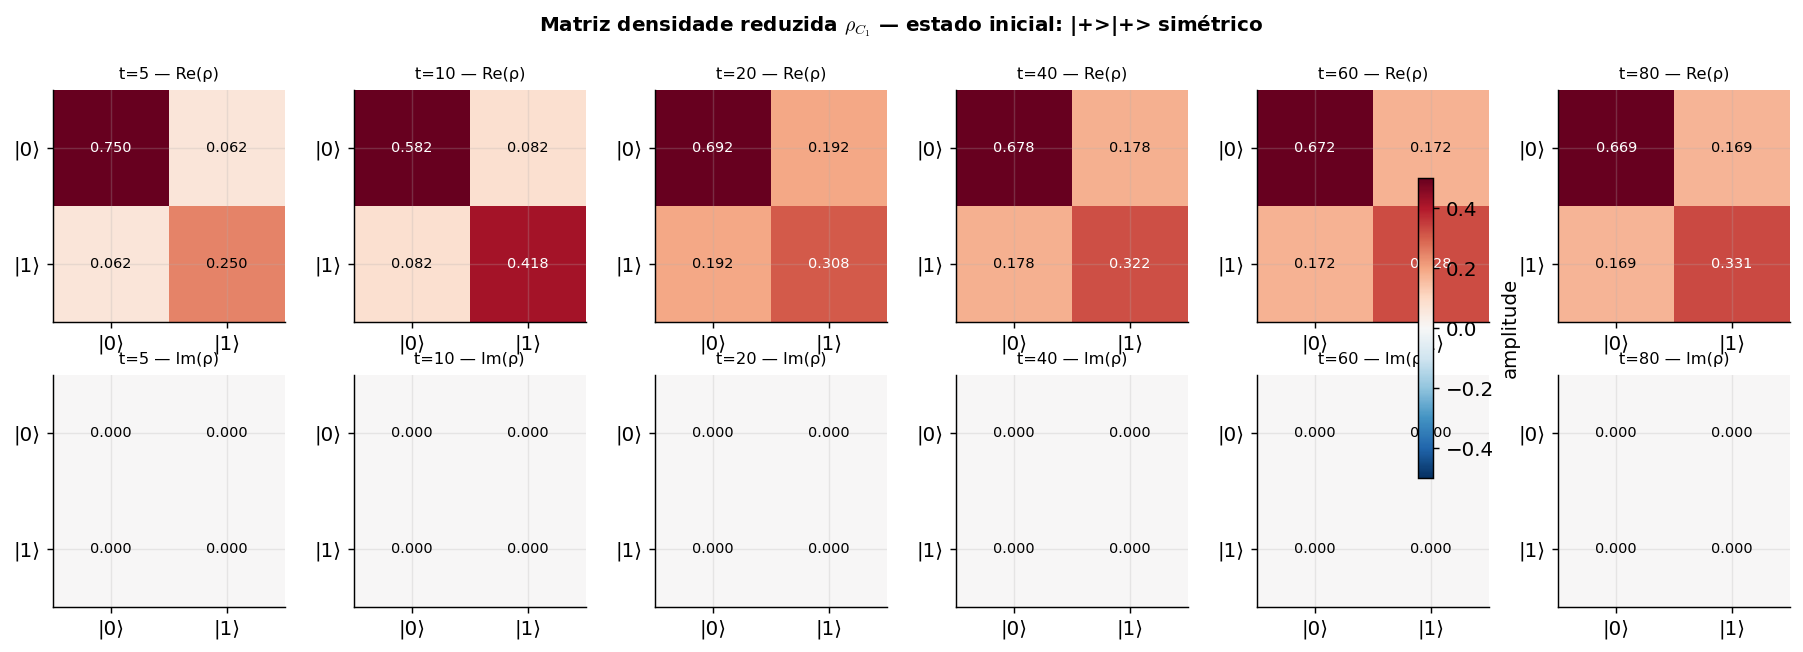

Figura salva: walk_density_matrix.png


In [11]:
snapshots = [5, 10, 20, 40, 60, N_STEPS]
snap_results = {}
for ns in snapshots:
    if ns <= N_STEPS:
        r = quantum_walk_2coins(ns, INITIAL_STATES[COIN_INIT_KEY])
        snap_results[ns] = reduced_density_coin1(r["state"])

fig, axes = plt.subplots(2, len(snap_results), figsize=(14, 5))

for col, (ns, rho) in enumerate(snap_results.items()):
    for row, (mat, title) in enumerate([
        (rho.real, "Re(ρ)"),
        (rho.imag, "Im(ρ)"),
    ]):
        ax = axes[row, col]
        im = ax.imshow(mat, cmap="RdBu_r", vmin=-0.5, vmax=0.5,
                       interpolation="nearest")
        ax.set_xticks([0,1]); ax.set_xticklabels(["|0⟩","|1⟩"])
        ax.set_yticks([0,1]); ax.set_yticklabels(["|0⟩","|1⟩"])
        ax.set_title(f"t={ns} — {title}", fontsize=9)

        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center",
                        fontsize=8, color="black" if abs(mat[i,j]) < 0.3 else "white")

fig.colorbar(im, ax=axes, shrink=0.6, label="amplitude")
plt.suptitle(r"Matriz densidade reduzida $\rho_{C_1}$ — estado inicial: " + COIN_INIT_KEY,
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("walk_density_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: walk_density_matrix.png")


## 12. Scan: S_máxima em função do número de passos

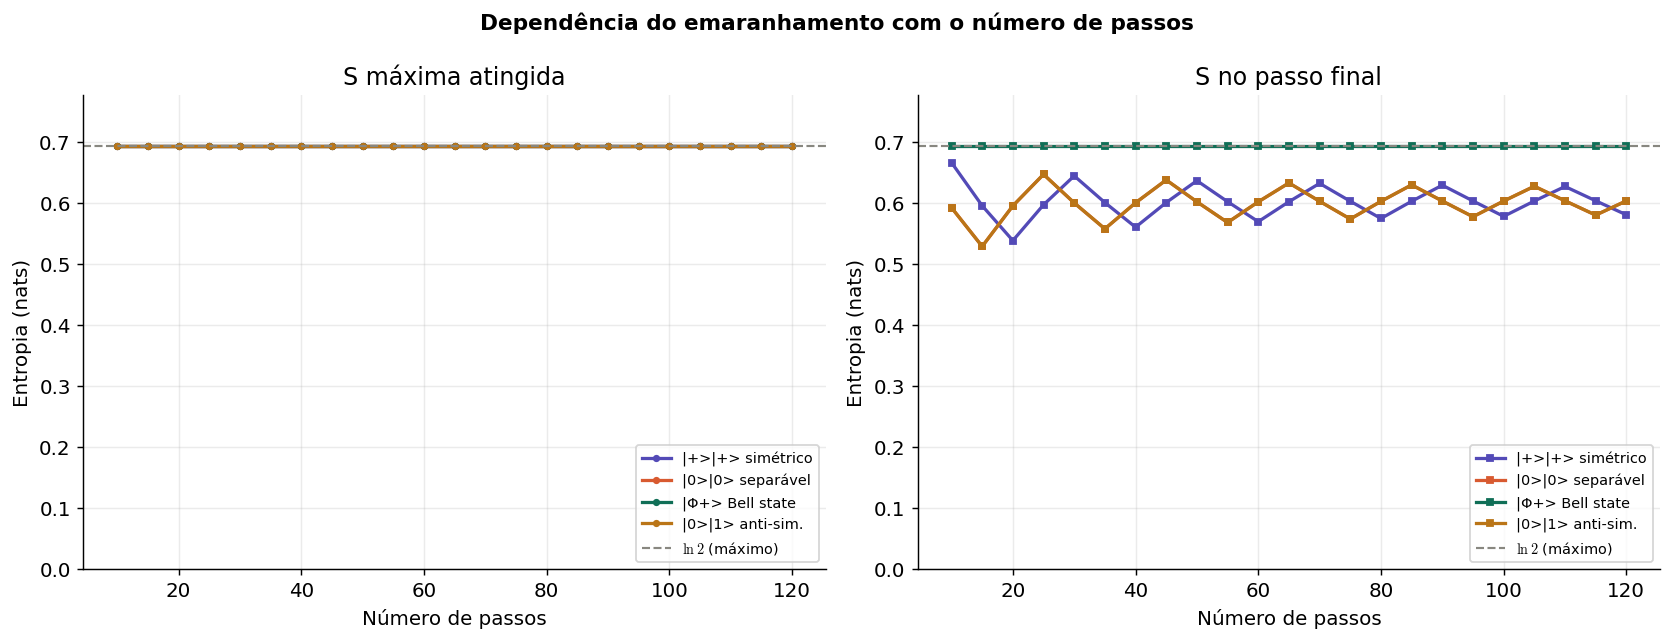

Figura salva: walk_entropy_vs_steps.png


In [12]:
step_range = np.arange(10, 121, 5)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (name, coinvec), col in zip(INITIAL_STATES.items(), colors):
    smax_vals = []
    sfin_vals = []
    for ns in step_range:
        r = quantum_walk_2coins(ns, coinvec)
        smax_vals.append(r["entropy"].max())
        sfin_vals.append(r["entropy"][-1])
    axes[0].plot(step_range, smax_vals, color=col, lw=1.8, marker="o",
                 markersize=3, label=name)
    axes[1].plot(step_range, sfin_vals, color=col, lw=1.8, marker="s",
                 markersize=3, label=name)

for ax, title in zip(axes, ["S máxima atingida", "S no passo final"]):
    ax.axhline(LN2, color="#888780", lw=1.2, ls="--",
               label=r"$\ln 2$ (máximo)")
    ax.set_xlabel("Número de passos")
    ax.set_ylabel("Entropia (nats)")
    ax.set_title(title)
    ax.set_ylim(0, LN2 * 1.12)
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Dependência do emaranhamento com o número de passos",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("walk_entropy_vs_steps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: walk_entropy_vs_steps.png")


## 13. Comparação de distribuições: todos os estados iniciais

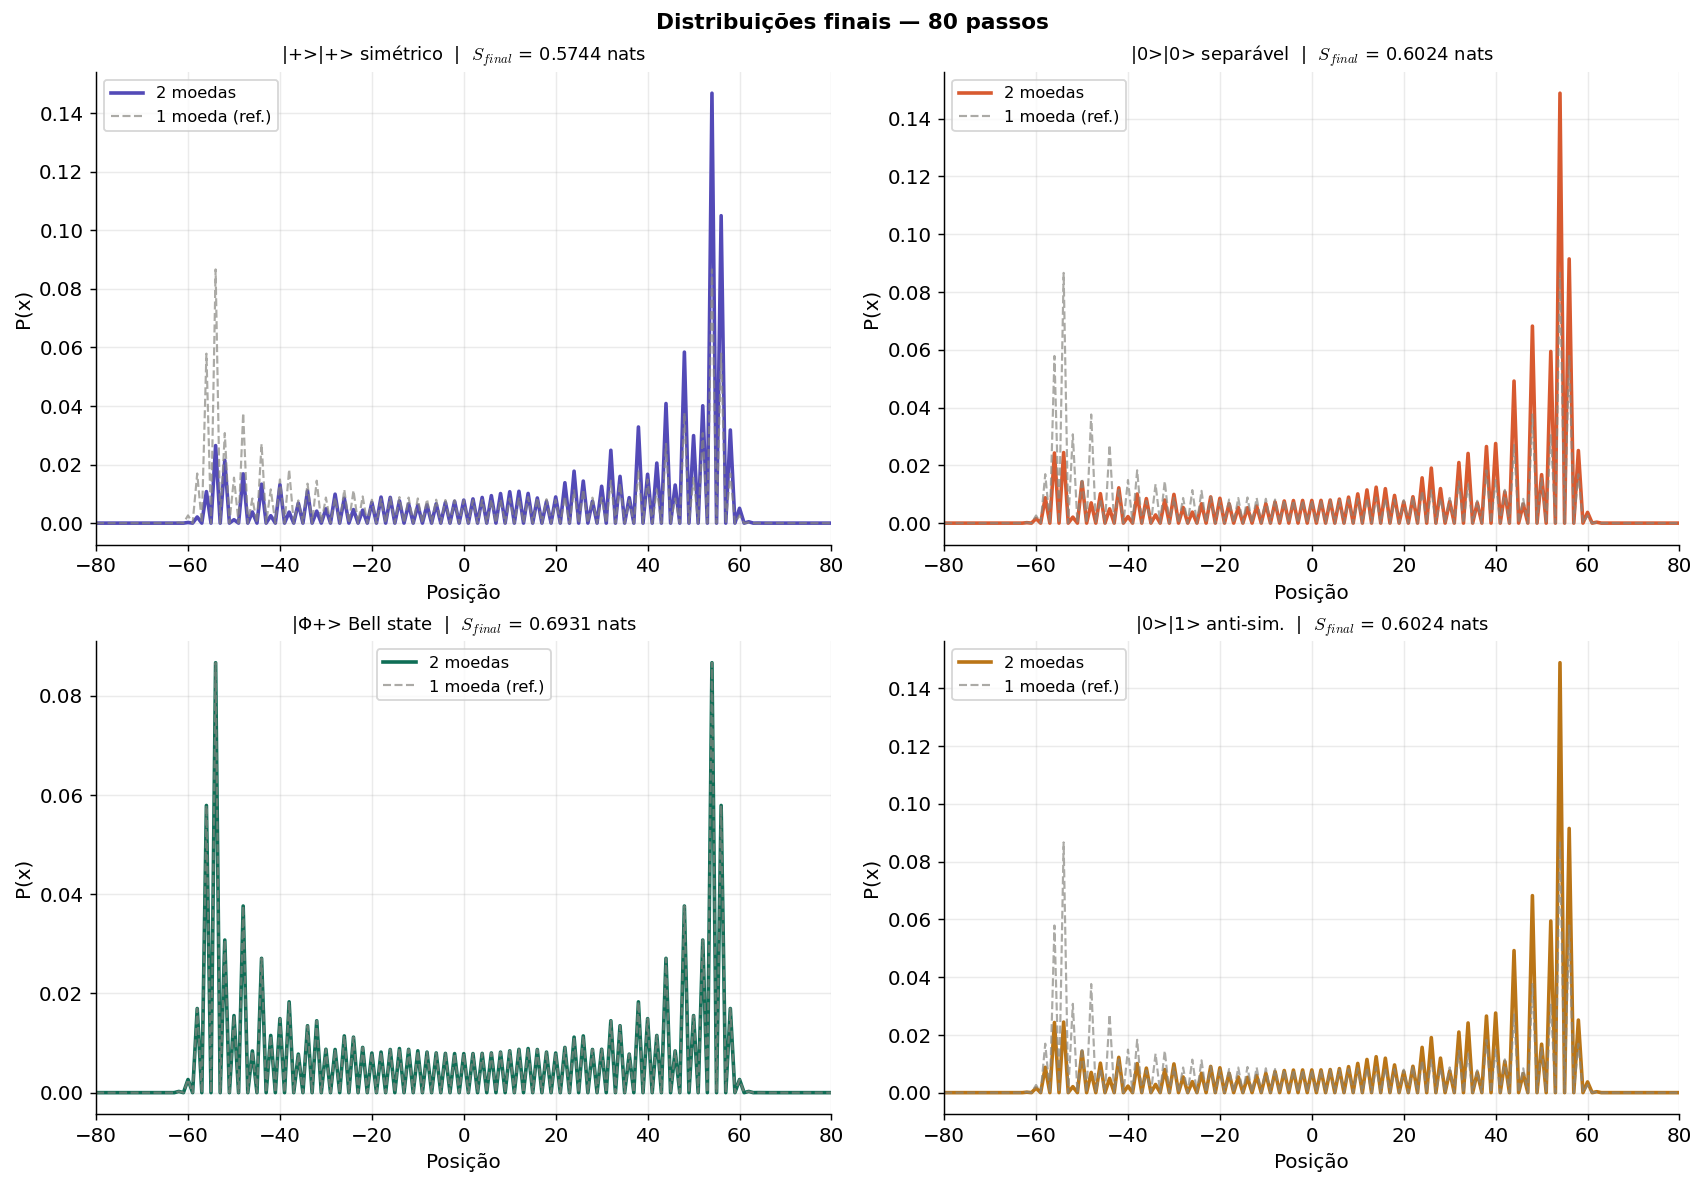

Figura salva: walk_distributions_all.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
ref = quantum_walk_1coin(N_STEPS)

for ax, (name, coinvec), col in zip(axes.flat, INITIAL_STATES.items(), colors):
    res = quantum_walk_2coins(N_STEPS, coinvec)
    ax.plot(res["positions"], res["prob"], color=col, lw=2.0, label="2 moedas")
    ax.plot(ref["positions"], ref["prob"], color="#888780", lw=1.2,
            ls="--", alpha=0.7, label="1 moeda (ref.)")
    S_fin = res["entropy"][-1]
    ax.set_title(f"{name}  |  $S_{{final}}$ = {S_fin:.4f} nats", fontsize=10)
    ax.set_xlabel("Posição"); ax.set_ylabel("P(x)")
    ax.set_xlim(-N_STEPS, N_STEPS)
    ax.legend(fontsize=9)

plt.suptitle(f"Distribuições finais — {N_STEPS} passos", fontsize=12, fontweight="bold")
plt.savefig("walk_distributions_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: walk_distributions_all.png")


## 14. Painel executivo — resumo completo

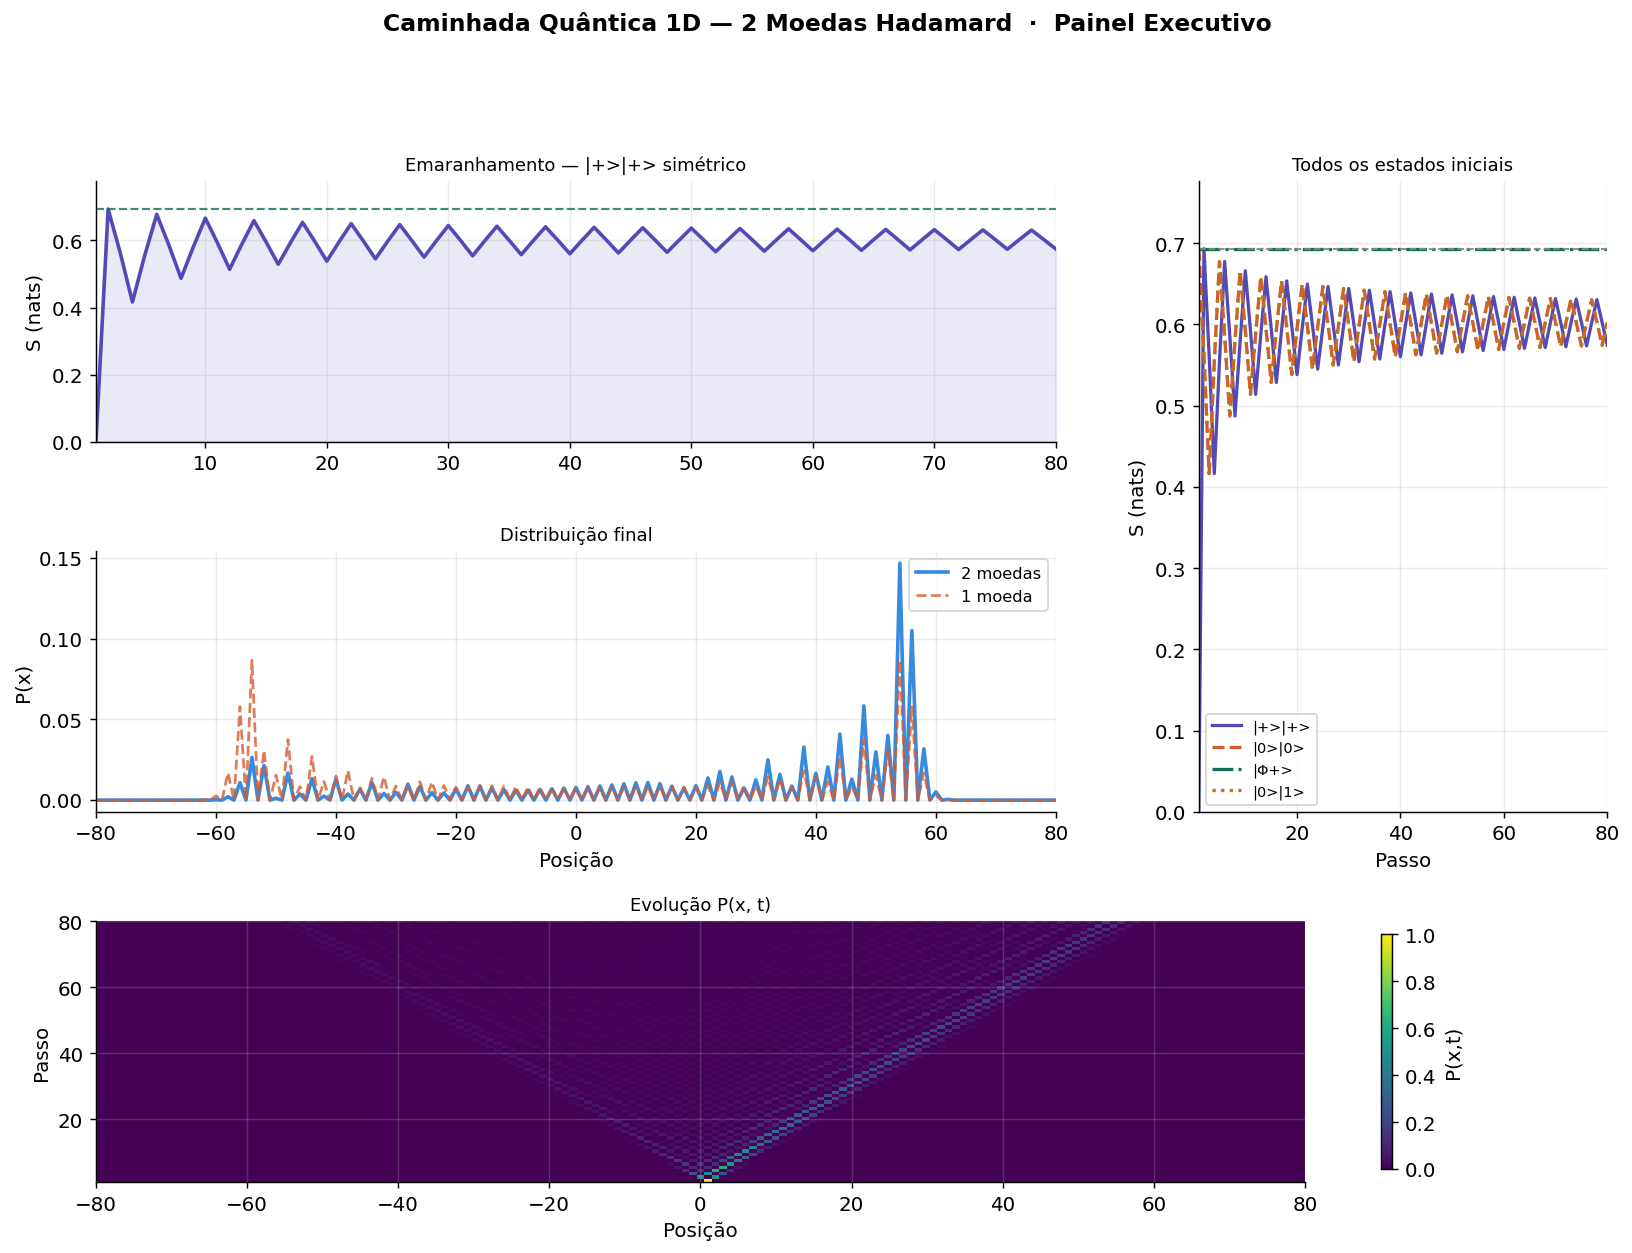

Figura salva: walk_dashboard.png


In [14]:
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

ax_ent   = fig.add_subplot(gs[0, :2])   # entropia principal
ax_dist  = fig.add_subplot(gs[1, :2])   # distribuição final
ax_comp  = fig.add_subplot(gs[0:2, 2])  # comparação todos os estados
ax_hm    = fig.add_subplot(gs[2, :])    # heatmap

# ── Entropia principal ────────────────────────────────────────────────────────
res_main = quantum_walk_2coins(N_STEPS, INITIAL_STATES[COIN_INIT_KEY])
steps_arr = np.arange(1, N_STEPS + 1)

ax_ent.fill_between(steps_arr, res_main["entropy"], alpha=0.12, color="#534AB7")
ax_ent.plot(steps_arr, res_main["entropy"], color="#534AB7", lw=2.0)
ax_ent.axhline(LN2, color="#0F6E56", lw=1.2, ls="--", alpha=0.8)
ax_ent.set_ylabel("S (nats)")
ax_ent.set_title(f"Emaranhamento — {COIN_INIT_KEY}", fontsize=10)
ax_ent.set_xlim(1, N_STEPS); ax_ent.set_ylim(0, LN2 * 1.12)

# ── Distribuição final ────────────────────────────────────────────────────────
ax_dist.plot(res_main["positions"], res_main["prob"],
             color="#378ADD", lw=2.0, label="2 moedas")
ax_dist.plot(ref["positions"], ref["prob"],
             color="#D85A30", lw=1.5, ls="--", alpha=0.8, label="1 moeda")
ax_dist.set_xlabel("Posição"); ax_dist.set_ylabel("P(x)")
ax_dist.set_title("Distribuição final", fontsize=10)
ax_dist.set_xlim(-N_STEPS, N_STEPS)
ax_dist.legend(fontsize=9)

# ── Comparação de estados iniciais ───────────────────────────────────────────
for (name, coinvec), col, ls in zip(INITIAL_STATES.items(), colors, linestyles):
    r = quantum_walk_2coins(N_STEPS, coinvec)
    ax_comp.plot(steps_arr, r["entropy"], color=col, ls=ls, lw=1.8,
                 label=name.split()[0])
ax_comp.axhline(LN2, color="#888780", lw=1, ls="--")
ax_comp.set_xlabel("Passo"); ax_comp.set_ylabel("S (nats)")
ax_comp.set_title("Todos os estados iniciais", fontsize=10)
ax_comp.set_xlim(1, N_STEPS); ax_comp.set_ylim(0, LN2 * 1.12)
ax_comp.legend(fontsize=8)

# ── Heatmap de evolução ────────────────────────────────────────────────────────
probs_hm = []
n_pos_hm = 2 * N_STEPS + 1
center_hm = N_STEPS
state_hm  = np.zeros((n_pos_hm, 4), dtype=complex)
state_hm[center_hm] = INITIAL_STATES[COIN_INIT_KEY] / np.linalg.norm(INITIAL_STATES[COIN_INIT_KEY])

for step in range(N_STEPS):
    state_hm = coin_operator_2(state_hm)
    state_hm = shift_operator_2(state_hm)
    probs_hm.append(np.sum(np.abs(state_hm)**2, axis=1).copy())

P_hm = np.array(probs_hm)
positions_hm = np.arange(n_pos_hm) - center_hm

im = ax_hm.imshow(P_hm, aspect="auto", origin="lower", cmap="viridis",
                  extent=[positions_hm[0], positions_hm[-1], 1, N_STEPS],
                  interpolation="nearest")
fig.colorbar(im, ax=ax_hm, label="P(x,t)", shrink=0.9)
ax_hm.set_xlabel("Posição"); ax_hm.set_ylabel("Passo")
ax_hm.set_title("Evolução P(x, t)", fontsize=10)

plt.suptitle("Caminhada Quântica 1D — 2 Moedas Hadamard  ·  Painel Executivo",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("walk_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: walk_dashboard.png")


## 15. Resumo numérico

In [15]:
print("=" * 62)
print(f"{'Estado inicial':<26} {'S_max':>8} {'t(S_max)':>9} {'S_final':>9}")
print("-" * 62)
for name, coinvec in INITIAL_STATES.items():
    r = quantum_walk_2coins(N_STEPS, coinvec)
    smax  = r["entropy"].max()
    tmax  = r["entropy"].argmax() + 1
    sfin  = r["entropy"][-1]
    print(f"{name:<26} {smax:>8.5f} {tmax:>9d} {sfin:>9.5f}")
print("-" * 62)
print(f"  ln(2) = {LN2:.6f} nats  (máximo para 1 qubit)")
print("=" * 62)


Estado inicial                S_max  t(S_max)   S_final
--------------------------------------------------------------
|+>|+> simétrico            0.69315         2   0.57437
|0>|0> separável            0.69315         1   0.60244
|Φ+> Bell state             0.69315        80   0.69315
|0>|1> anti-sim.            0.69315         1   0.60244
--------------------------------------------------------------
  ln(2) = 0.693147 nats  (máximo para 1 qubit)
